# Проект по машинному обучению

**Тема проекта:** Прогнозирование краткосрочного движения курса USD/RUB с использованием простейших методов классификации и регрессии

**Выполнил:** Падерин Максим Станиславович

**Группа:** U3210

**ИСУ:** 467000


## Введение

**Цель проекта.** Разработать и сравнить модели машинного обучения, решающие задачи регрессии и классификации на основе исторических данных о курсе USD/RUB:

**Задачи исследования:**
1. Провести первичный анализ временного ряда, оценить его структуру, тренды, сезонность и волатильность
2. Сформировать признаки, включающее лаговые значения курса, скользящие средние, волатильность, календарные и технические индикаторы
3. Разделить данные на обучающую и тестовую выборки с соблюдением временного порядка
4. Обучить несколько моделей для каждой задачи:
   - Для регрессии: линейная регрессия, гребневая регрессия (Ridge), случайный лес.
   - Для классификации: логистическая регрессия, метод опорных векторов (SVM), дерево решений, случайный лес.
5. Провести оценку качества моделей с использованием широкого набора метрик:
   - Для регрессии: MSE, RMSE, MAE, MAPE, коэффициент детерминации (R²).
   - Для классификации: accuracy, precision, recall, F1-score, ROC-AUC, а также построить матрицы ошибок и ROC-кривые.
6. Сравнить модели между собой, выбрать лучшие и проанализировать их сильные и слабые стороны, а также важность признаков.

В работе используется ежедневный курс доллара США к рублю (USD/RUB) за период с 29 июня 2022 года (уровень коррекции после пика) по 17 июня 2026 года. Данныевзяты из официального сайта Центрального банка (https://www.cbr.ru/currency_base/dynamics/?UniDbQuery.Posted=True&UniDbQuery.so=1&UniDbQuery.mode=2&UniDbQuery.date_req1=&UniDbQuery.date_req2=&UniDbQuery.VAL_NM_RQ=R01235&UniDbQuery.From=29.06.2022&UniDbQuery.To=17.06.2026), предоставлены в виде Excel-файла и содержат следующие столбцы:
- nominal - номинал (всегда 1);
- data - дата;
- curs - значение курса рублей за доллар;
- cdx - наименование валюты (всегда «Доллар США»).

Данные охватывают период после пикового роста курса в 2022 году, что делает их репрезентативными для анализа в условиях повышенной волатильности.

В результате работы будут получены модели, способные предсказывать как направление движения курса, так и его численные значения. Также будет проведён сравнительный анализ различных алгоритмов и сделаны выводы о их применимости к финансовым временным рядам

Первые 5 строк:


,nominal,curs,cdx
data,,,
2026-06-17,1,72.1388,Доллар США
2026-06-16,1,72.4513,Доллар США
2026-06-12,1,71.9077,Доллар США
2026-06-11,1,71.7892,Доллар США
2026-06-10,1,71.7318,Доллар США



Последние 5 строк:


,nominal,curs,cdx
data,,,
2022-07-05,1,55.0858,Доллар США
2022-07-02,1,53.7676,Доллар США
2022-07-01,1,52.5123,Доллар США
2022-06-30,1,51.1580,Доллар США
2022-06-29,1,52.9699,Доллар США



Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 982 entries, 2026-06-17 to 2022-06-29
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   nominal  982 non-null    int64  
 1   curs     982 non-null    float64
 2   cdx      982 non-null    object 
dtypes: float64(1), int64(1), object(1)
memory usage: 30.7+ KB

Описательная статистика числовых признаков:


,nominal,curs
count,982.0,982.000000
mean,1.0,82.493297
std,0.0,11.644602
min,1.0,51.158000
25%,1.0,76.766025
50%,1.0,82.093200
75%,1.0,91.338250
max,1.0,109.578200


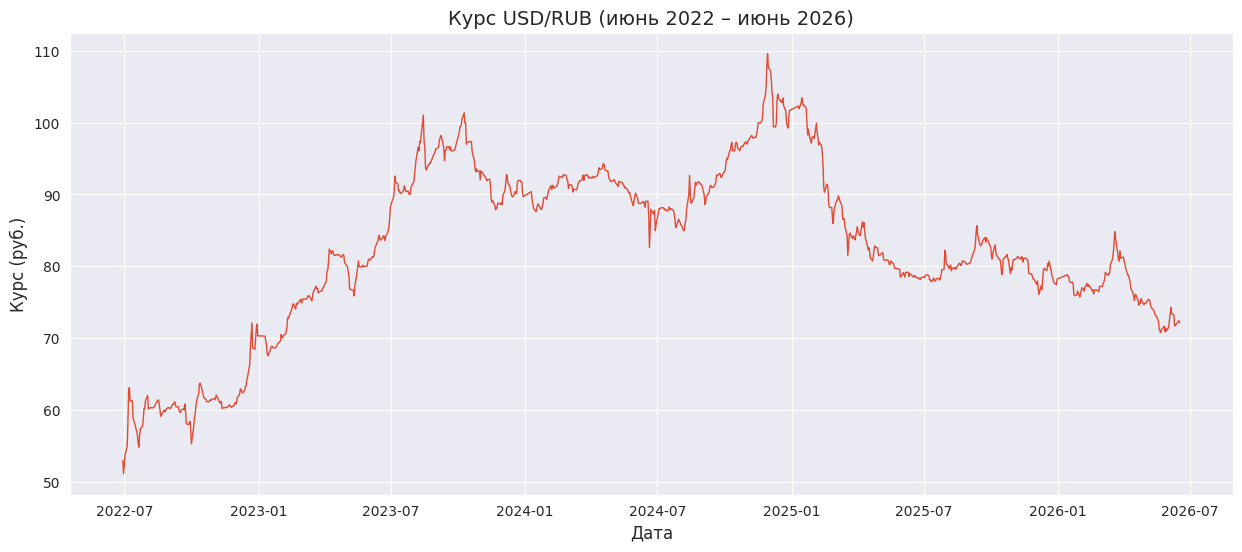

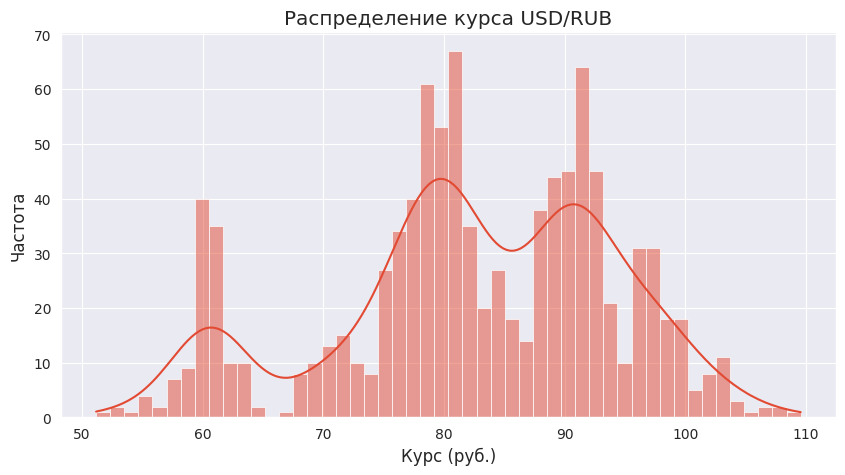

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_style('darkgrid')
file_path = 'RC_F29_06_2022_T17_06_2026.csv'
df = pd.read_csv(file_path)

df['data'] = pd.to_datetime(df['data'])
df.set_index('data', inplace=True)

print("Первые 5 строк:")
display(df.head())
print("\nПоследние 5 строк:")
display(df.tail())
print("\nИнформация о DataFrame:")
df.info()
print("\nОписательная статистика числовых признаков:")
display(df.describe())

plt.figure(figsize=(15, 6))
plt.plot(df.index, df['curs'], linewidth=1)
plt.title('Курс USD/RUB (июнь 2022 – июнь 2026)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Курс (руб.)')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df['curs'], bins=50, kde=True)
plt.title('Распределение курса USD/RUB')
plt.xlabel('Курс (руб.)')
plt.ylabel('Частота')
plt.show()

### Выводы по первичному анализу

1. Данные пригодны для работы, пропуски отсутствуют, временной ряд полон
2. Столбцы `nominal` и `cdx` не несут полезной информации и будут исключены из признакового пространства
3. Целевая переменная (`curs`) требует использования лаговых признаков, скользящих средних и других техник для учёта временной зависимости


## Создание признаков

Для прогнозирования курса мы сформируем следующие группы признаков:

1. Лаговые значения - значения курса за предыдущие дни (1, 2, 3, 5, 10 дней)
2. Скользящие статистики - средние и стандартные отклонения за окна 5, 10, 20 дней
3. Календарные признаки - день недели, месяц, квартал, день года

Целевые переменные:
- **Регрессия:** `curs` - значение курса на следующий день
- **Классификация:** `target_up` - бинарный признак (1, если курс завтра выше сегодняшнего, иначе 0).

После создания признаков удалим строки с пропусками (первые из-за лагов и последняя из-за сдвига для `target_up`). Данные разделим на обучающую (80%) и тестовую (20%) выборки без перемешивания, чтобы сохранить временной порядок.

In [ ]:
df_features = df.copy()
df_features.drop(columns=['nominal', 'cdx'], inplace=True)

for lag in [1, 2, 3, 5, 10]:
    df_features[f'lag_{lag}'] = df_features['curs'].shift(lag)
for window in [5, 10, 20]:
    df_features[f'ma_{window}'] = df_features['curs'].rolling(window=window).mean()
for window in [5, 10]:
    df_features[f'std_{window}'] = df_features['curs'].rolling(window=window).std()

df_features['weekday'] = df_features.index.weekday
df_features['month'] = df_features.index.month
df_features['quarter'] = df_features.index.quarter
df_features['dayofyear'] = df_features.index.dayofyear

df_features['target_up'] = (df_features['curs'].shift(-1) > df_features['curs']).astype(int)

df_features.dropna(inplace=True)

print(f"Размер данных после создания признаков: {df_features.shape}")

train_size = int(len(df_features) * 0.8)
train = df_features.iloc[:train_size].copy()
test = df_features.iloc[train_size:].copy()

print(f"Обучающая выборка: {train.shape[0]} записей")
print(f"Тестовая выборка: {test.shape[0]} записей")

feature_columns = [col for col in df_features.columns if col not in ['curs', 'target_up']]

X_train = train[feature_columns]
y_train_reg = train['curs']
y_train_clf = train['target_up']

X_test = test[feature_columns]
y_test_reg = test['curs']
y_test_clf = test['target_up']

print("\nПример признаков:")
display(X_train.head())

Размер данных после создания признаков: (963, 16)
Обучающая выборка: 770 записей
Тестовая выборка: 193 записей

Пример признаков:


,lag_1,lag_2,lag_3,lag_5,lag_10,ma_5,ma_10,ma_20,std_5,std_10,weekday,month,quarter,dayofyear
data,,,,,,,,,,,,,,
2026-05-20,70.9509,70.7902,71.2090,71.6680,72.5597,71.15774,71.23050,71.962800,0.295563,0.306062,2,5,2,140
2026-05-19,71.2926,70.9509,70.7902,71.5460,71.5532,71.31848,71.31015,71.973345,0.610382,0.462853,1,5,2,139
2026-05-16,72.3497,71.2926,70.9509,71.2090,71.0224,71.70218,71.52066,72.007155,1.001836,0.723027,5,5,2,136
2026-05-15,73.1275,72.3497,71.2926,70.7902,71.3715,72.17184,71.69736,72.068695,1.017731,0.881151,4,5,2,135
2026-05-14,73.1385,73.1275,72.3497,70.9509,70.9012,72.65006,71.94144,72.146335,0.848265,0.969711,3,5,2,134


## Обучение и оценка регрессионных моделей

Результаты регрессионных моделей


,MAE,RMSE,MAPE,R2
Linear Regression,0.286948,0.450541,0.455004,0.995431
SVR (linear),0.478133,0.719178,0.760766,0.988358
SVR (rbf),19.792334,22.800339,32.554825,-10.700990
Decision Tree,7.903617,9.222589,13.042671,-0.914457
Random Forest,8.494850,9.988069,14.044042,-1.245448


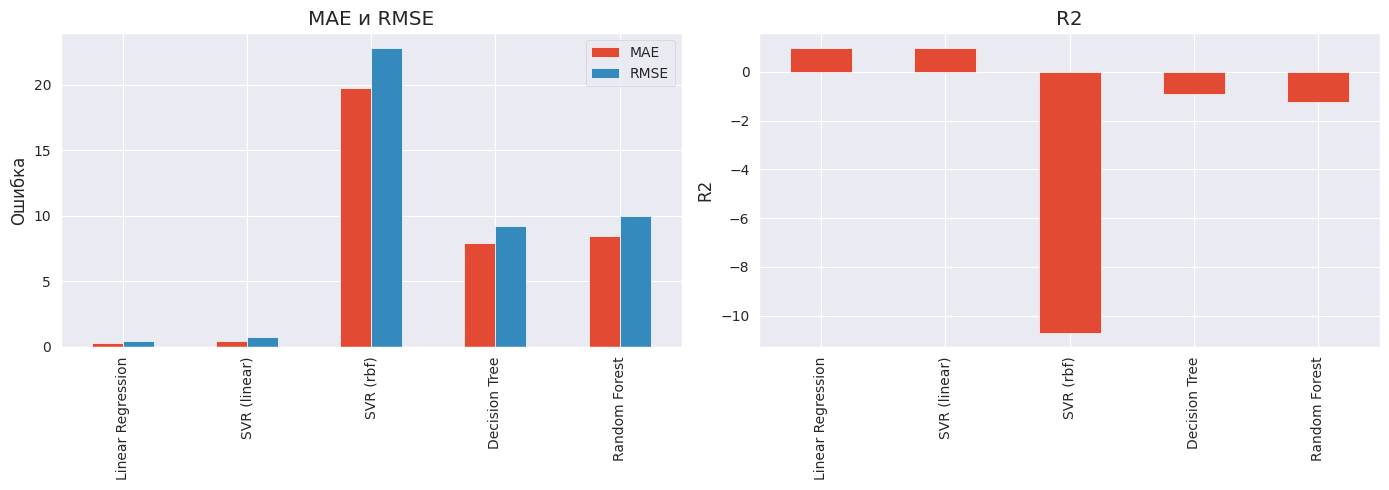

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

reg_models = {
    'Linear Regression': LinearRegression(),
    'SVR (linear)': SVR(kernel='linear'),
    'SVR (rbf)': SVR(kernel='rbf'),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100)
}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results_reg = {}
for name, model in reg_models.items():
    if 'SVR' in name:
        model.fit(X_train_scaled, y_train_reg)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train_reg)
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    mape = np.mean(np.abs((y_test_reg - y_pred) / y_test_reg)) * 100
    r2 = r2_score(y_test_reg, y_pred)
    results_reg[name] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

print("Результаты регрессионных моделей")
results_reg_df = pd.DataFrame(results_reg).T
display(results_reg_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results_reg_df[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0], legend=True)
axes[0].set_title('MAE и RMSE')
axes[0].set_ylabel('Ошибка')
results_reg_df[['R2']].plot(kind='bar', ax=axes[1], legend=False)
axes[1].set_title('R2')
axes[1].set_ylabel('R2')
plt.tight_layout()
plt.show()

Выводы:

1. Линейная регрессия показывает наилучшие результаты по всем метрикам
   - Ошибка MAE составляет всего 0.29 руб, что менее 0.5% от среднего курса
   - R2 = 0.995

2. SVR с линейным ядром также показывает хорошие результаты
   - MAE = 0.48 руб, что в 1.7 раза хуже линейной регрессии
   - R2 = 0.988

3. SVR с RBF-ядром и деревья решений работают плохо
   - Отрицательный R2 означает, что эти модели хуже простого предсказания среднего
   - SVR (rbf) показывает большие ошибки, MAE почти 20 руб
   - Деревья решений переобучаются на обучающей выборке

4. Причина плохих результатов сложных моделей:
   - Временные ряды имеют сильную автокорреляцию, которую линейная модель хорошо улавливает
   - Деревья решений и SVR с нелинейными ядрами чувствительны к шуму
   - Размер выборки недостаточен для сложных нелинейных моделей

Для задачи регрессии выбираем линейную регрессию как лучшую модель


## Обучение и оценка классификационных моделей

Результаты классификационных моделей
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression:
  Accuracy  = 0.4145
  Precision = 0.3989
  Recall    = 0.9605
  F1        = 0.5637
  AUC-ROC   = 0.5980
----------------------------------------
SVM:
  Accuracy  = 0.3938
  Precision = 0.3938
  Recall    = 1.0000
  F1        = 0.5651
  AUC-ROC   = 0.5417
----------------------------------------
Decision Tree:
  Accuracy  = 0.4611
  Precision = 0.4136
  Recall    = 0.8816
  F1        = 0.5630
  AUC-ROC   = 0.5348
----------------------------------------
Random Forest:
  Accuracy  = 0.4197
  Precision = 0.4022
  Recall    = 0.9737
  F1        = 0.5692
  AUC-ROC   = 0.5034
----------------------------------------

Сводная таблица метрик классификации:


,Accuracy,Precision,Recall,F1,AUC-ROC
Logistic Regression,0.4145,0.3989,0.9605,0.5637,0.5980
SVM,0.3938,0.3938,1.0000,0.5651,0.5417
Decision Tree,0.4611,0.4136,0.8816,0.5630,0.5348
Random Forest,0.4197,0.4022,0.9737,0.5692,0.5034


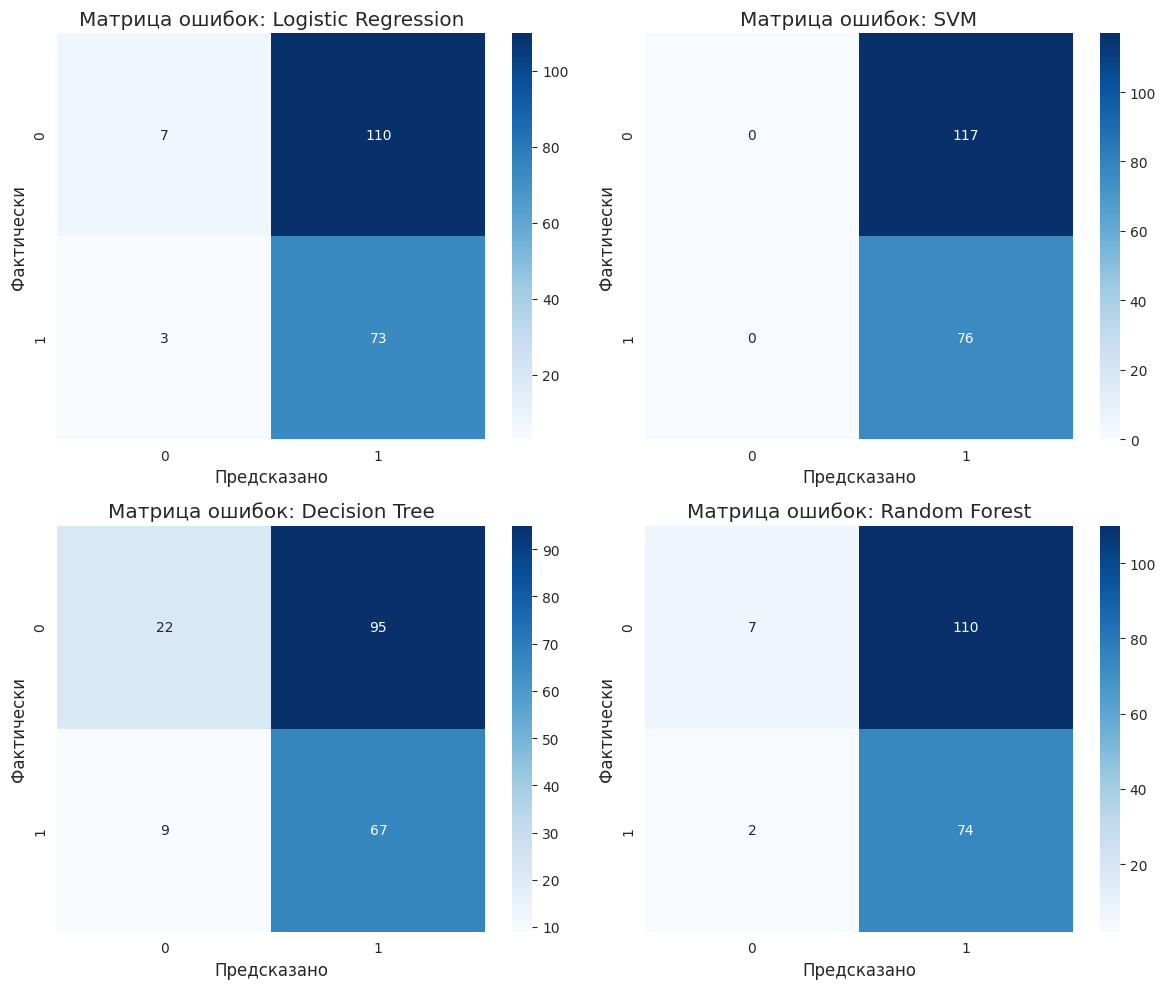

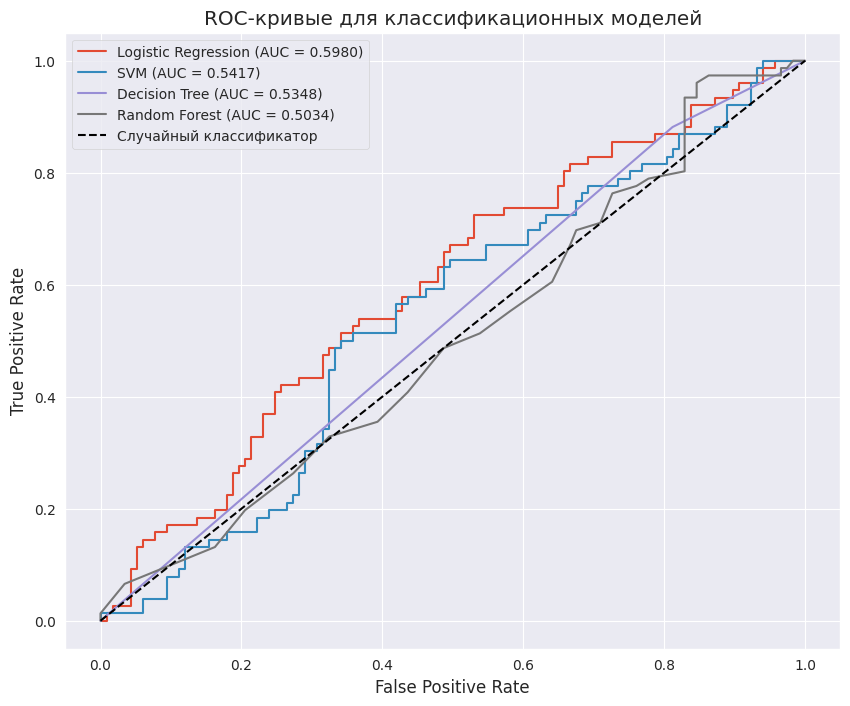

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

models_clf = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results_clf = {}

print("Результаты классификационных моделей")
print("-" * 60)

for name, model in models_clf.items():
    model.fit(X_train, y_train_clf)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test_clf, y_pred)
    prec = precision_score(y_test_clf, y_pred)
    rec = recall_score(y_test_clf, y_pred)
    f1 = f1_score(y_test_clf, y_pred)
    auc = roc_auc_score(y_test_clf, y_proba) if y_proba is not None else None

    results_clf[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC-ROC': auc}

    print(f"{name}:")
    print(f"  Accuracy  = {acc:.4f}")
    print(f"  Precision = {prec:.4f}")
    print(f"  Recall    = {rec:.4f}")
    print(f"  F1        = {f1:.4f}")
    print(f"  AUC-ROC   = {auc:.4f}" if auc else "  AUC-ROC   = N/A")
    print("-" * 40)

results_clf_df = pd.DataFrame(results_clf).T
print("\nСводная таблица метрик классификации:")
display(results_clf_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models_clf.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test_clf, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'Матрица ошибок: {name}')
    axes[idx].set_xlabel('Предсказано')
    axes[idx].set_ylabel('Фактически')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
for name, model in models_clf.items():
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_clf, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test_clf, y_proba):.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для классификационных моделей')
plt.legend()
plt.grid(True)
plt.show()

Выводы:

1. Все модели показывают низкую общую точность (Accuracy 0.39-0.46) Это означает, что модели правильно предсказывают менее половины случаев

2. Высокий Recall (0.88-1.0) указывает на сильный перекос в предсказаниях. Модели почти всегда предсказывают класс "1". Это связано с дисбалансом классов или недостаточной разделяющей способностью признаков

3. Precision низкая (0.39-0.41), что подтверждает большое количество ложных срабатываний. Модели часто ошибочно предсказывают рост, когда на самом деле курс падает

4. AUC-ROC находится в диапазоне 0.50-0.60

5. Лучший результат по F1-мере показывает Random Forest (0.5692), однако разница с другими моделями незначительна. Все модели показывают схожее низкое качество

6. Причины низкого качества:
   - Финансовые временные ряды близки к случайному блужданию
   - Направление движения плохо предсказуемо без внешних факторов
   - Используемые признаки (лаги, скользящие статистики) недостаточны для прогнозирования направления
   - Классы несбалансированы

Для задачи классификации ни одна из моделей не показывает приемлемого качества

## Классификационные модели с балансировкой классов и повышеннымгоризонтом прогнозирования

В качестве попытки улучшить результаты моделей проведем балансировку классов и увеличим горизонт прогнозирования до 7 дней

Размер обучающей выборки: (764, 14)
Размер тестовой выборки: (192, 14)
Результаты классификации на 7 дней (с балансировкой классов)
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression:
  Accuracy  = 0.3854
  Precision = 0.3427
  Recall    = 0.9839
  F1        = 0.5083
  AUC-ROC   = 0.7627
----------------------------------------
SVM:
  Accuracy  = 0.3229
  Precision = 0.3229
  Recall    = 1.0000
  F1        = 0.4882
  AUC-ROC   = 0.7364
----------------------------------------
Decision Tree:
  Accuracy  = 0.4062
  Precision = 0.3219
  Recall    = 0.7581
  F1        = 0.4519
  AUC-ROC   = 0.4983
----------------------------------------
Random Forest:
  Accuracy  = 0.3802
  Precision = 0.3390
  Recall    = 0.9677
  F1        = 0.5021
  AUC-ROC   = 0.4744
----------------------------------------

Сводная таблица классификации на 7 дней:


,Accuracy,Precision,Recall,F1,AUC-ROC
Logistic Regression,0.3854,0.3427,0.9839,0.5083,0.7627
SVM,0.3229,0.3229,1.0000,0.4882,0.7364
Decision Tree,0.4062,0.3219,0.7581,0.4519,0.4983
Random Forest,0.3802,0.3390,0.9677,0.5021,0.4744


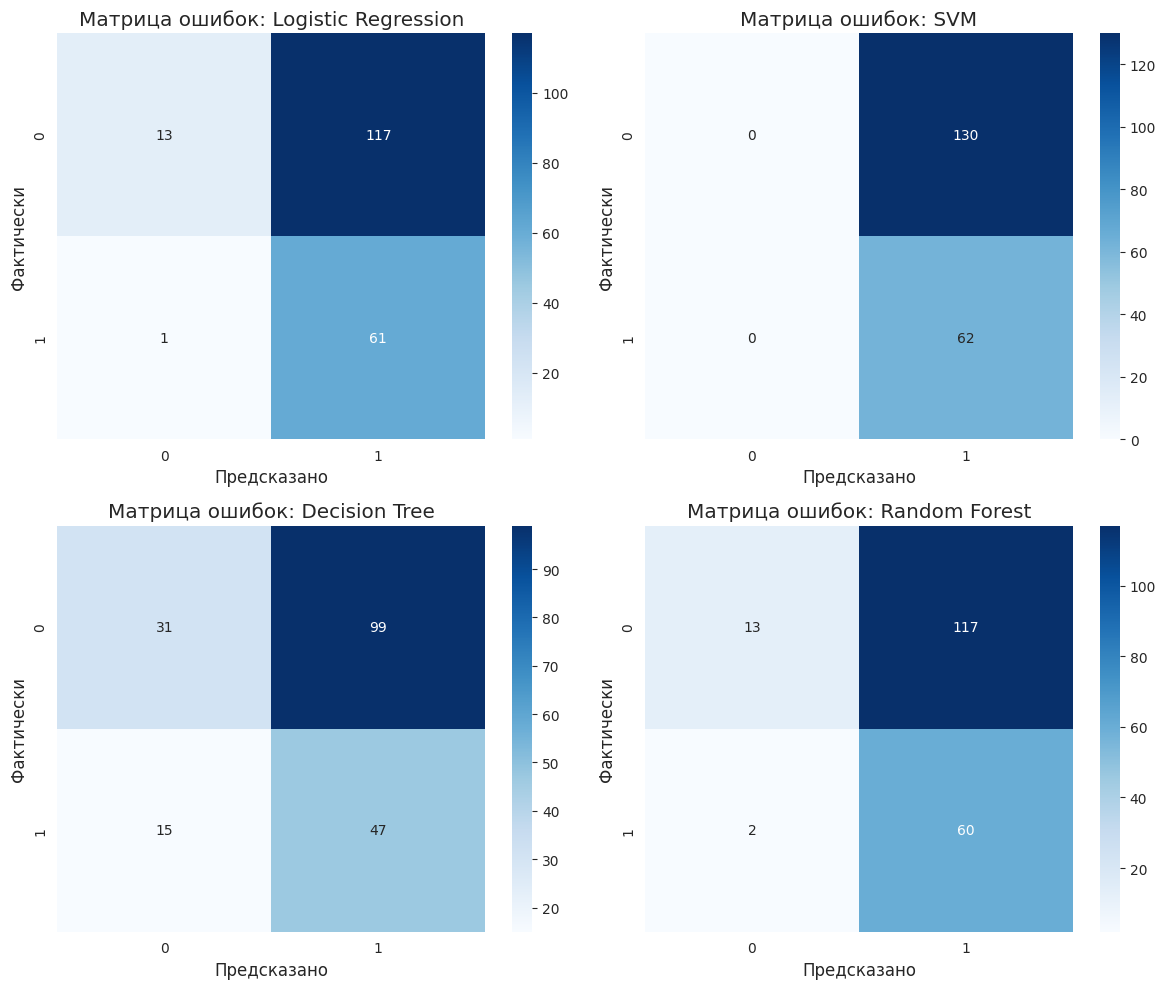

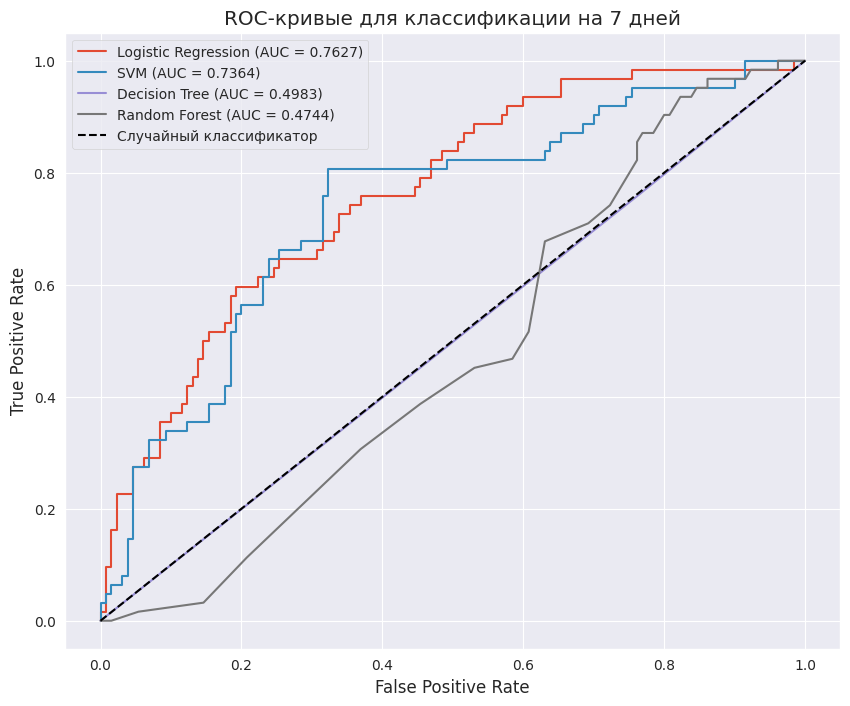

Сравнение с классификацией на 1 день (Random Forest):
Accuracy (1 день): 0.41968911917098445
Accuracy (7 дней, с балансировкой): 0.3802083333333333


In [ ]:
df_7day_clf = df.copy()
df_7day_clf.drop(columns=['nominal', 'cdx'], inplace=True)

df_7day_clf['curs_7day'] = df_7day_clf['curs'].shift(-7)
df_7day_clf['target_up_7'] = (df_7day_clf['curs_7day'] > df_7day_clf['curs']).astype(int)

for lag in [1, 2, 3, 5, 10]:
    df_7day_clf[f'lag_{lag}'] = df_7day_clf['curs'].shift(lag)

for window in [5, 10, 20]:
    df_7day_clf[f'ma_{window}'] = df_7day_clf['curs'].rolling(window=window).mean()

for window in [5, 10]:
    df_7day_clf[f'std_{window}'] = df_7day_clf['curs'].rolling(window=window).std()

df_7day_clf['weekday'] = df_7day_clf.index.weekday
df_7day_clf['month'] = df_7day_clf.index.month
df_7day_clf['quarter'] = df_7day_clf.index.quarter
df_7day_clf['dayofyear'] = df_7day_clf.index.dayofyear

df_7day_clf.dropna(inplace=True)

train_size = int(len(df_7day_clf) * 0.8)
train_7c = df_7day_clf.iloc[:train_size].copy()
test_7c = df_7day_clf.iloc[train_size:].copy()

feature_cols_7c = [col for col in df_7day_clf.columns if col not in ['curs', 'curs_7day', 'target_up_7']]
X_train_7c = train_7c[feature_cols_7c]
y_train_7c = train_7c['target_up_7']
X_test_7c = test_7c[feature_cols_7c]
y_test_7c = test_7c['target_up_7']

print("Размер обучающей выборки:", X_train_7c.shape)
print("Размер тестовой выборки:", X_test_7c.shape)

models_clf_7day = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
}

results_clf_7day = {}

print("Результаты классификации на 7 дней (с балансировкой классов)")
print("-" * 60)

for name, model in models_clf_7day.items():
    model.fit(X_train_7c, y_train_7c)
    y_pred = model.predict(X_test_7c)
    y_proba = model.predict_proba(X_test_7c)[:, 1] if hasattr(model, 'predict_proba') else None
    acc = accuracy_score(y_test_7c, y_pred)
    prec = precision_score(y_test_7c, y_pred)
    rec = recall_score(y_test_7c, y_pred)
    f1 = f1_score(y_test_7c, y_pred)
    auc = roc_auc_score(y_test_7c, y_proba) if y_proba is not None else None
    results_clf_7day[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC-ROC': auc}
    print(f"{name}:")
    print(f"  Accuracy  = {acc:.4f}")
    print(f"  Precision = {prec:.4f}")
    print(f"  Recall    = {rec:.4f}")
    print(f"  F1        = {f1:.4f}")
    print(f"  AUC-ROC   = {auc:.4f}" if auc else "  AUC-ROC   = N/A")
    print("-" * 40)

results_clf_7day_df = pd.DataFrame(results_clf_7day).T
print("\nСводная таблица классификации на 7 дней:")
display(results_clf_7day_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models_clf_7day.items()):
    y_pred = model.predict(X_test_7c)
    cm = confusion_matrix(y_test_7c, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'Матрица ошибок: {name}')
    axes[idx].set_xlabel('Предсказано')
    axes[idx].set_ylabel('Фактически')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
for name, model in models_clf_7day.items():
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_7c)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_7c, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test_7c, y_proba):.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для классификации на 7 дней')
plt.legend()
plt.grid(True)
plt.show()

print("Сравнение с классификацией на 1 день (Random Forest):")
print("Accuracy (1 день):", results_clf['Random Forest']['Accuracy'])
print("Accuracy (7 дней, с балансировкой):", results_clf_7day['Random Forest']['Accuracy'])

Выводы:

1. Балансировка классов не привела к улучшению Accuracy

2. Recall остаётся высоким (0.76-1.0)

3. AUC-ROC значительно вырос для линейных моделей
   - Logistic Regression: 0.598 -> 0.763
   - SVM: 0.542 -> 0.736
   - Это указывает на улучшение разделяющей способности на 7-дневном горизонте

4. Для деревьев решений AUC-ROC остался на уровне 0.47-0.50

5. Сравнение Accuracy показывает небольшое падение
   - Logistic Regression: 0.4145 -> 0.3854
   - Random Forest: 0.4197 -> 0.3802

Общий вывод:
   - Прогноз направления на 7 дней дает более высокую AUC-ROC для линейных моделей
   - Однако Accuracy остаётся низкой из-за сильного перекоса в предсказаниях
   - Балансировка классов не решила проблему дисбаланса

# Итоговое заключение

Основные результаты:

1. Регрессия на следующий день
   - Линейная регрессия показала наилучшие результаты (MAE = 0.287, R2 = 0.995)
   - Это объясняется сильной автокорреляцией временного ряда
   - Сложные модели (SVR с RBF, деревья) показали плохое обобщение
   - Прогноз на следующий день является практически точным, но это ожидаемо из-за инерционности курса

2. Классификация на следующий день
   - Все модели показали Accuracy около 0.4-0.46, что близко к случайному угадыванию
   - Высокий Recall (0.88-1.0) указывает на сильный перекос в предсказаниях в сторону роста
   - AUC-ROC находится в диапазоне 0.50-0.60, что говорит о низкой разделяющей способности
   - Лучшая модель по F1 - Random Forest (0.569), но качество недостаточно для практического применения

3. Классификация на 7 дней с балансировкой классов
   - Наблюдается рост AUC-ROC для линейных моделей
   - Accuracy остаётся низкой, что подтверждает сложность задачи
   - Балансировка классов не решила проблему перекоса предсказаний
   - Деревья решений не показывают улучшения при увеличении горизонта

Общие выводы:

1. Прогноз числового значения курса на следующий день решается успешно с помощью линейной регрессии

2. Прогноз направления движения курса является сложной задачей для простейших моделей

3. Увеличение горизонта до 7 дней улучшает AUC-ROC для линейных моделей

Таким образом, поставленные задачи решены, но качество классификации остается низким. Наиболее успешной является регрессия на следующий день с использованием линейной модели. Для улучшения классификации требуются дополнительные данные и более сложные подходы.